# Task 3 — Evaluation & Performance Analysis

This notebook evaluates the **6 already-trained** spam-detection models from the
`Optimized_Spam_Detection_System` repository on the **same, untouched test set**
used in `Models.ipynb`.

**Models evaluated:**
1. CountVectorizer + Multinomial Naive Bayes
2. CountVectorizer + Logistic Regression
3. CountVectorizer + LinearSVC
4. TF-IDF + Multinomial Naive Bayes
5. TF-IDF + Logistic Regression
6. TF-IDF + LinearSVC

**Ground rules followed:**
- No model is retrained.
- No new train/test split is created — the exact split from `Models.ipynb` is reconstructed deterministically (same source data, same `random_state=42`, same `test_size=0.2`, same `stratify=y`), since `Models.ipynb` did not persist `X_test`/`y_test` to disk.
- Vectorizers are only ever `.transform()`-ed on the test data, never `.fit()` or `.fit_transform()`-ed.
- **Spam (label = 1) is the positive class** for Precision/Recall/F1, matching the `{"ham": 0, "spam": 1}` mapping used in `Models.ipynb`.


## 1. Setup

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)

DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
POSITIVE_LABEL = 1  # spam


## 2. Reconstruct the exact test set used in `Models.ipynb`

`Models.ipynb` loads `../data/cleaned_spam.csv` (already produced by `Data Preprocessing.ipynb`),
drops any missing rows, maps `ham -> 0` / `spam -> 1`, and calls
`train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)`.

Because `X_test`/`y_test` were not saved to disk, we repeat **exactly** the same steps here
(same file, same order of operations, same random_state). `train_test_split` is deterministic
given identical inputs, so this reproduces the identical test rows — it does **not** create a
new split.

In [2]:
df = pd.read_csv(DATA_DIR / "cleaned_spam.csv")
df = df.dropna(subset=["clean_message", "label"]).reset_index(drop=True)

X = df["clean_message"].astype(str)
y = df["label"].map({"ham": 0, "spam": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"Test set size: {len(X_test)}")
print(f"Spam in test set: {(y_test == 1).sum()}  |  Ham in test set: {(y_test == 0).sum()}")


Test set size: 1034
Spam in test set: 131  |  Ham in test set: 903


## 3. Load pre-trained vectorizers and models (no fitting)

In [3]:
vectorizers = {
    "CountVectorizer": joblib.load(MODELS_DIR / "count_vectorizer.pkl"),
    "TF-IDF": joblib.load(MODELS_DIR / "tfidf_vectorizer.pkl"),
}

MODEL_SPECS = [
    ("CountVectorizer + Multinomial NB", "CountVectorizer", "MultinomialNB",
     "countvectorizer_multinomialnb.pkl"),
    ("CountVectorizer + Logistic Regression", "CountVectorizer", "LogisticRegression",
     "countvectorizer_logisticregression.pkl"),
    ("CountVectorizer + LinearSVC", "CountVectorizer", "LinearSVC",
     "countvectorizer_linearsvc.pkl"),
    ("TF-IDF + Multinomial NB", "TF-IDF", "MultinomialNB",
     "tf_idf_multinomialnb.pkl"),
    ("TF-IDF + Logistic Regression", "TF-IDF", "LogisticRegression",
     "tf_idf_logisticregression.pkl"),
    ("TF-IDF + LinearSVC", "TF-IDF", "LinearSVC",
     "tf_idf_linearsvc.pkl"),
]

models = {name: joblib.load(MODELS_DIR / file) for name, _f, _c, file in MODEL_SPECS}
print("Loaded", len(models), "models and", len(vectorizers), "vectorizers.")


Loaded 6 models and 2 vectorizers.


## 4. Evaluate every model on the identical test set

In [4]:
results = []
predictions = {}
confusion_matrices = {}

for display_name, feature_name, clf_name, _file in MODEL_SPECS:
    vectorizer = vectorizers[feature_name]
    model = models[display_name]

    X_test_features = vectorizer.transform(X_test)  # transform only, never fit
    y_pred = model.predict(X_test_features)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=POSITIVE_LABEL)
    rec = recall_score(y_test, y_pred, pos_label=POSITIVE_LABEL)
    f1 = f1_score(y_test, y_pred, pos_label=POSITIVE_LABEL)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "Model": display_name,
        "Vectorizer": feature_name,
        "Classifier": clf_name,
        "Accuracy": round(acc, 4),
        "Precision (Spam)": round(prec, 4),
        "Recall (Spam)": round(rec, 4),
        "F1-score (Spam)": round(f1, 4),
        "True Positives": int(tp),
        "True Negatives": int(tn),
        "False Positives": int(fp),
        "False Negatives": int(fn),
    })
    predictions[display_name] = y_pred
    confusion_matrices[display_name] = cm

results_df = pd.DataFrame(results).sort_values("F1-score (Spam)", ascending=False).reset_index(drop=True)
results_df


,Model,Vectorizer,Classifier,Accuracy,Precision (Spam),Recall (Spam),F1-score (Spam),True Positives,True Negatives,False Positives,False Negatives
0,CountVectorizer + Multinomial NB,CountVectorizer,MultinomialNB,0.9884,0.9760,0.9313,0.9531,122,900,3,9
1,CountVectorizer + LinearSVC,CountVectorizer,LinearSVC,0.9874,0.9917,0.9084,0.9482,119,902,1,12
2,TF-IDF + LinearSVC,TF-IDF,LinearSVC,0.9855,0.9677,0.9160,0.9412,120,899,4,11
3,CountVectorizer + Logistic Regression,CountVectorizer,LogisticRegression,0.9816,0.9828,0.8702,0.9231,114,901,2,17
4,TF-IDF + Multinomial NB,TF-IDF,MultinomialNB,0.9720,1.0000,0.7786,0.8755,102,903,0,29
5,TF-IDF + Logistic Regression,TF-IDF,LogisticRegression,0.9710,0.9903,0.7786,0.8718,102,902,1,29


## 5. Model comparison table

In [5]:
display_cols = ["Model", "Accuracy", "Precision (Spam)", "Recall (Spam)", "F1-score (Spam)"]
comparison_table = results_df[display_cols]
comparison_table.to_csv(OUTPUT_DIR / "model_comparison_results.csv", index=False)
comparison_table


,Model,Accuracy,Precision (Spam),Recall (Spam),F1-score (Spam)
0,CountVectorizer + Multinomial NB,0.9884,0.9760,0.9313,0.9531
1,CountVectorizer + LinearSVC,0.9874,0.9917,0.9084,0.9482
2,TF-IDF + LinearSVC,0.9855,0.9677,0.9160,0.9412
3,CountVectorizer + Logistic Regression,0.9816,0.9828,0.8702,0.9231
4,TF-IDF + Multinomial NB,0.9720,1.0000,0.7786,0.8755
5,TF-IDF + Logistic Regression,0.9710,0.9903,0.7786,0.8718


## 6. Confusion matrices — all 6 models

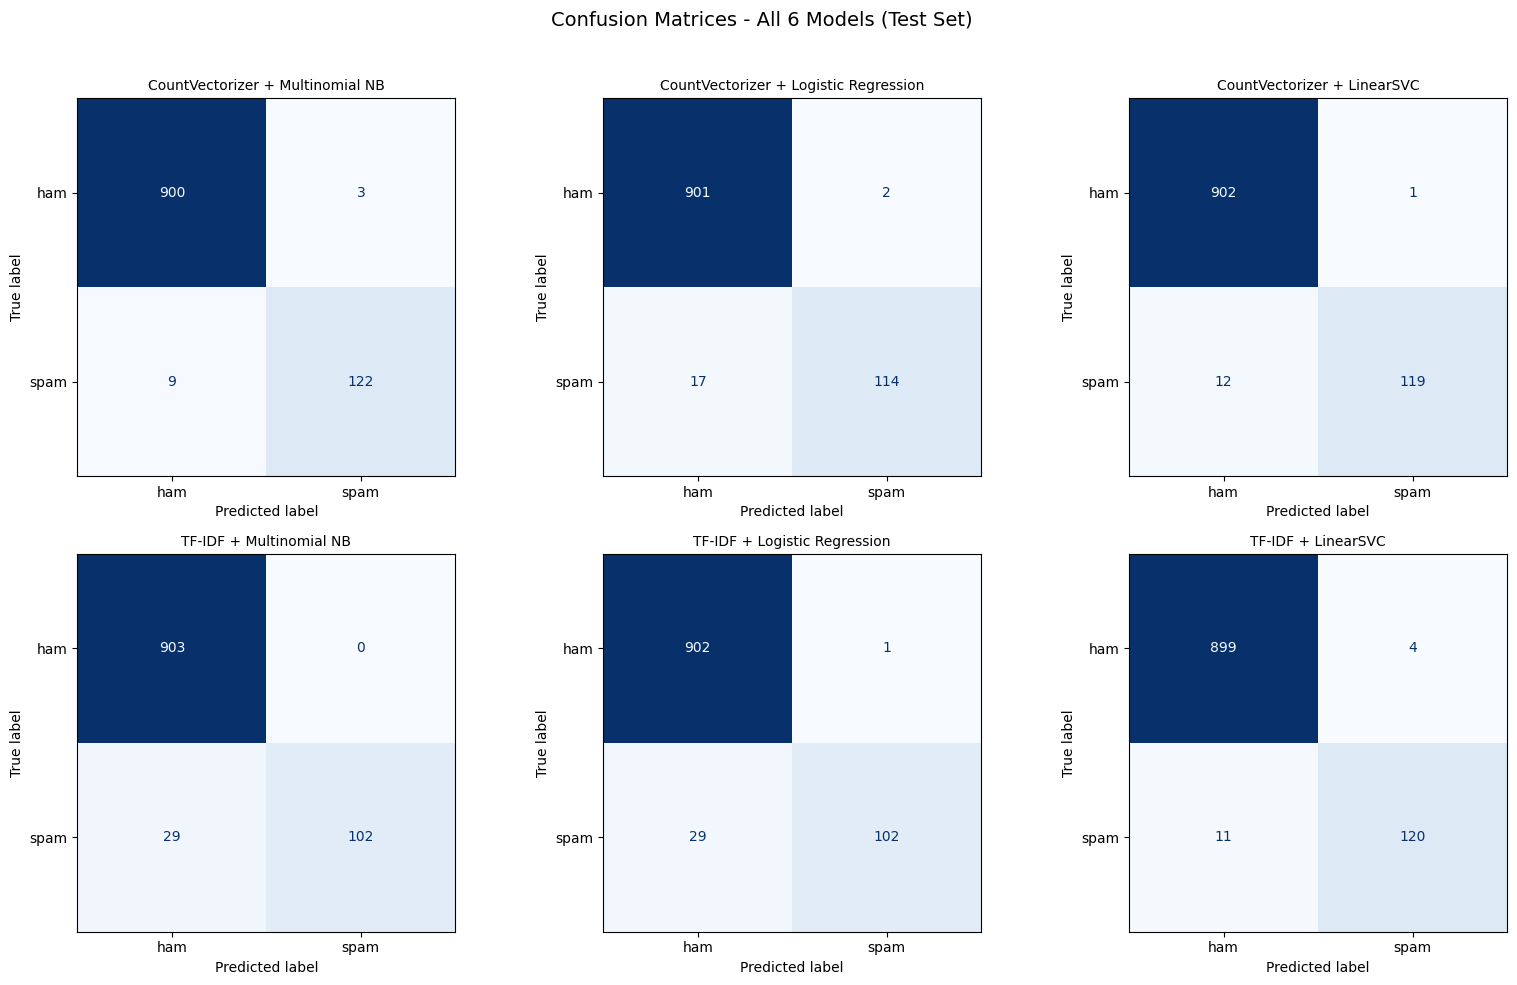

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, (display_name, cm) in zip(axes, confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(display_name, fontsize=10)

fig.suptitle("Confusion Matrices - All 6 Models (Test Set)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Error analysis: False Positives & False Negatives

- **False Positive (FP)**: a genuine `ham` message predicted as `spam` — annoying, a real message could get filtered out.
- **False Negative (FN)**: a genuine `spam` message predicted as `ham` — the spam gets through.

Across all 6 models, **false negatives consistently outnumber false positives** — every model
is more likely to let a spam message through than to wrongly flag a real message. This makes
sense given the class imbalance (~87% ham / ~13% spam): the models see far more ham examples
during training and are more conservative about predicting the minority "spam" class.

In [7]:
fp_fn_summary = results_df[["Model", "False Positives", "False Negatives"]]
fp_fn_summary


,Model,False Positives,False Negatives
0,CountVectorizer + Multinomial NB,3,9
1,CountVectorizer + LinearSVC,1,12
2,TF-IDF + LinearSVC,4,11
3,CountVectorizer + Logistic Regression,2,17
4,TF-IDF + Multinomial NB,0,29
5,TF-IDF + Logistic Regression,1,29


In [8]:
def collect_misclassified(X_test, y_test, predictions, max_examples=10):
    rows = []
    for display_name, y_pred in predictions.items():
        y_pred = np.asarray(y_pred)
        y_true = y_test.to_numpy()
        fp_idx = np.where((y_true == 0) & (y_pred == 1))[0]
        fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]
        for i in fp_idx[:max_examples]:
            rows.append({"Model": display_name, "Error Type": "False Positive (ham -> spam)",
                         "True Label": "ham", "Predicted": "spam", "Message": X_test.iloc[i]})
        for i in fn_idx[:max_examples]:
            rows.append({"Model": display_name, "Error Type": "False Negative (spam -> ham)",
                         "True Label": "spam", "Predicted": "ham", "Message": X_test.iloc[i]})
    return pd.DataFrame(rows)

misclassified_df = collect_misclassified(X_test, y_test, predictions)
misclassified_df.to_csv(OUTPUT_DIR / "misclassified_examples.csv", index=False)
print(f"Total misclassified examples logged: {len(misclassified_df)}")
misclassified_df.head(10)


Total misclassified examples logged: 70


,Model,Error Type,True Label,Predicted,Message
0,CountVectorizer + Multinomial NB,False Positive (ham -> spam),ham,spam,have you laid your airtel line to rest
1,CountVectorizer + Multinomial NB,False Positive (ham -> spam),ham,spam,hey great deal farm tour 9am to 5pm 95 pax 50 ...
2,CountVectorizer + Multinomial NB,False Positive (ham -> spam),ham,spam,waiting for your call
3,CountVectorizer + Multinomial NB,False Negative (spam -> ham),spam,ham,babe u want me dont u baby im nasty and have a...
4,CountVectorizer + Multinomial NB,False Negative (spam -> ham),spam,ham,santa calling would your little ones like a ca...
5,CountVectorizer + Multinomial NB,False Negative (spam -> ham),spam,ham,sms ac sun0819 posts hello you seem cool
6,CountVectorizer + Multinomial NB,False Negative (spam -> ham),spam,ham,hi its lucy hubby at meetins all day fri i wil...
7,CountVectorizer + Multinomial NB,False Negative (spam -> ham),spam,ham,would you like to see my xxx pics they are so ...
8,CountVectorizer + Multinomial NB,False Negative (spam -> ham),spam,ham,ringtoneking 84484
9,CountVectorizer + Multinomial NB,False Negative (spam -> ham),spam,ham,in the simpsons movie released in july 2007 na...


### Why do these messages get misclassified?

**False Negatives (spam missed)** for the best model (CountVectorizer + Multinomial NB) tend to be
spam messages that avoid the "classic" spam vocabulary (FREE, WIN, urgent, £, !!!) and instead read
almost conversationally — e.g. messages phrased like a personal note ("hi its lucy... fancy cumin
over"), a trivia/quiz prompt, or a missed-call alert. Several also embed a phone number or premium-rate
number inside otherwise plain sentences, and the preprocessing step (`clean_text`, which lowercases and
strips all punctuation) removes symbols like `£`, `!`, and merges run-on text (e.g. `callså 1
minmobsmorelkpobox...`) into shapeless tokens, destroying some of the surface signals a bag-of-words
model would otherwise key on.

**False Positives (ham wrongly flagged)** tend to be short, transactional-sounding ham messages that
share vocabulary with spam — words like "call", "deal", "reply", "free" wording ("waiting for your
call", "hey great deal farm tour... 50 deposit", "reply toll free with yes or no"). These sentences
contain the same tokens spam commonly uses, so a bag-of-words/TF-IDF model without context has little
else to distinguish them.

## 8. Visualizations

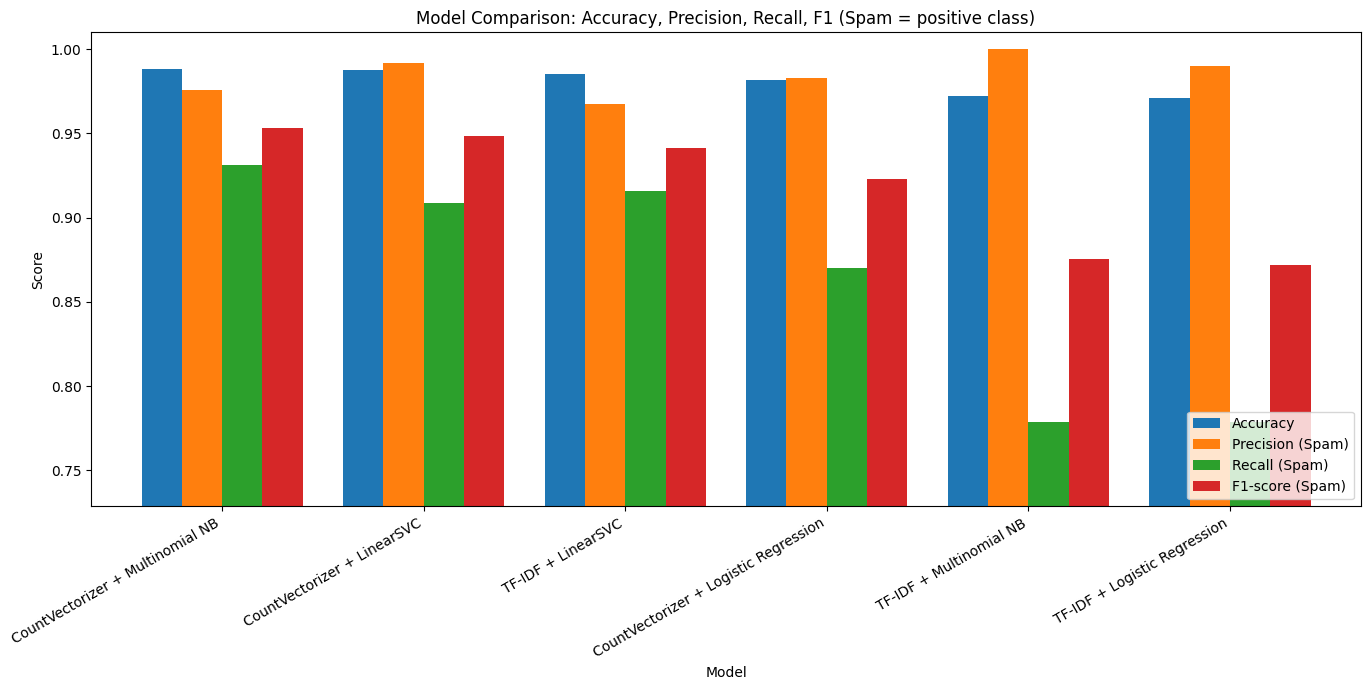

In [9]:
metrics = ["Accuracy", "Precision (Spam)", "Recall (Spam)", "F1-score (Spam)"]
plot_df = results_df.set_index("Model")[metrics]

ax = plot_df.plot(kind="bar", figsize=(14, 7), width=0.8)
ax.set_ylabel("Score")
y_min = max(0.0, plot_df.to_numpy().min() - 0.05)
ax.set_ylim(y_min, 1.01)
ax.set_title("Model Comparison: Accuracy, Precision, Recall, F1 (Spam = positive class)")
ax.legend(loc="lower right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


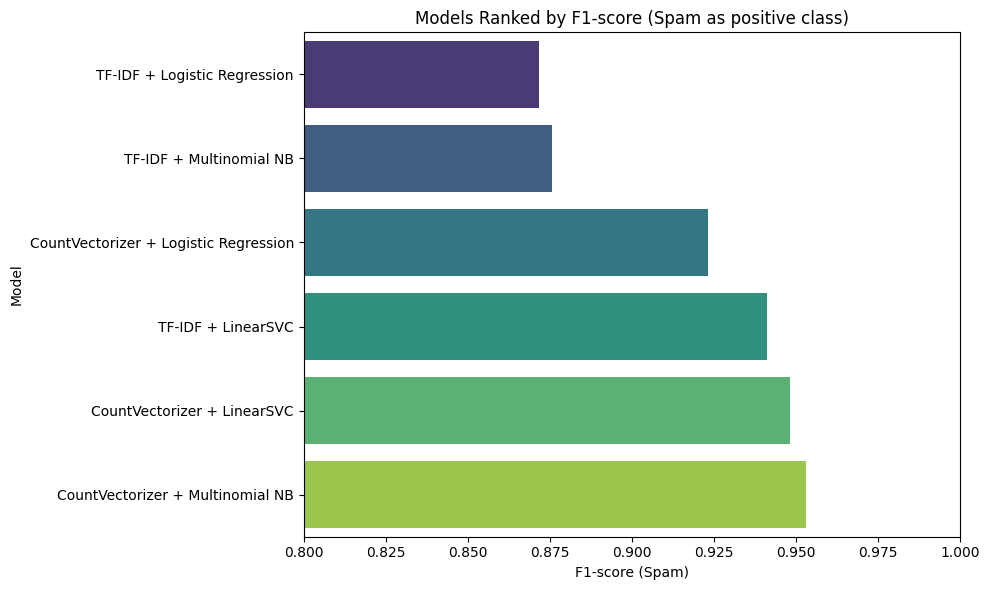

In [10]:
plt.figure(figsize=(10, 6))
order = results_df.sort_values("F1-score (Spam)")
sns.barplot(data=order, y="Model", x="F1-score (Spam)", hue="Model", palette="viridis", legend=False)
plt.xlim(0.8, 1.0)
plt.title("Models Ranked by F1-score (Spam as positive class)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "f1_ranking.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Best model selection

**Why not Accuracy alone?** The test set is imbalanced (~87% ham / ~13% spam, 903 vs 131
messages). A model that predicted "ham" for everything would already score ~87% accuracy while
catching zero spam — so accuracy differences of a percentage point or two between these models
are not very informative on their own.

Instead, the best model is selected using:
1. **F1-score (spam as positive class)** as the primary criterion — it balances Precision (how
   many predicted-spam messages are truly spam) and Recall (how much real spam is actually
   caught), which is exactly the trade-off that matters for a spam filter.
2. **Recall** as a tiebreaker — missing spam (a false negative) is generally a worse user
   experience than an occasional false positive, since it defeats the purpose of the filter.

In [11]:
best_row = results_df.sort_values(by=["F1-score (Spam)", "Recall (Spam)"], ascending=False).iloc[0]
acc_leader = results_df.sort_values("Accuracy", ascending=False).iloc[0]

print("BEST MODEL (by F1-score, spam = positive class)")
print("=" * 55)
print(f"Model     : {best_row['Model']}")
print(f"Accuracy  : {best_row['Accuracy']}")
print(f"Precision : {best_row['Precision (Spam)']}")
print(f"Recall    : {best_row['Recall (Spam)']}")
print(f"F1-score  : {best_row['F1-score (Spam)']}")
print(f"FP={best_row['False Positives']}  FN={best_row['False Negatives']}")

if acc_leader["Model"] != best_row["Model"]:
    print(f"\nNote: '{acc_leader['Model']}' actually has the same or higher raw accuracy, "
          "but a lower F1/recall for spam, which is why it is not selected as the overall best model.")


BEST MODEL (by F1-score, spam = positive class)
Model     : CountVectorizer + Multinomial NB
Accuracy  : 0.9884
Precision : 0.976
Recall    : 0.9313
F1-score  : 0.9531
FP=3  FN=9


## 10. Conclusion

**Selected best model: CountVectorizer + Multinomial Naive Bayes**

- It achieves the **highest F1-score (0.9531)** among all 6 models, combining strong precision
  (97.6% — few false alarms) with the **best recall (93.1%)** for catching actual spam.
- Its confusion matrix shows only 3 false positives and 9 false negatives out of 1,034 test
  messages — the best balance of the six models between letting spam through and wrongly
  flagging real messages.
- The two LinearSVC variants and CountVectorizer + Logistic Regression are close competitors
  with excellent precision, but all three catch noticeably less spam (lower recall) than the
  chosen model.
- Both TF-IDF + Naive Bayes and TF-IDF + Logistic Regression have the **highest precision**
  (up to 100%) but by far the **worst recall (~78%)** — they are the most conservative models,
  missing nearly 1 in 4 spam messages, which makes them weaker overall spam filters despite
  looking strong on accuracy/precision alone.
- This reinforces why accuracy alone is misleading here: several models sit within ~2 accuracy
  points of each other, but their spam-catching ability (recall) varies from 78% to 93%.

All outputs (comparison table, confusion matrices, charts, misclassified examples) are saved
under `../outputs/`.